## 지난주 개념 복습!
아래 마크다운을 풀고, 지난주 예습과제를 통해 공부한 Vision Transformer의 특징과 다른 모델들과의 차이점을 간략히 설명해주세요.

- 이미지를 작은 패치들로 나눠 각 패치 간의 상관관계를 학습한다. 셀프 어텐션 방법으로 모든 이미지 패치가 서로에게 주는 영향을 고려해 이미지의 전체 특징을 추출하므로 합성곱 신경망과 달리 모든 이미지 패치가 모든 부분 학습에 관여하게 된다.
- ViT는 이러한 이미지 패치의 크기가 고정되어 있어 semantic segmentation 작업에는 적합하지 않고 2차 계산 복잡도의 셀프 어텐션을 수행한다. 반면 스윈 트랜스포머는 계층적 특징 맵을 구성해 1차 계산 복잡도를 가지고, shifted window 기술로 계층마다 패치의 크기와 개수가 다양하다. CvT는 합성곱 임베딩을 사용해 지역 특징을 학습할 수 있고, 결과 배열의 길이를 줄이면서 토큰 특징의 차원을 증가시킬 수 있다.

## 파이토치로 구현한 Vision Transformer
이번 복습과제에서는 카사바 잎 질병 데이터셋으로 vision transformer를 학습시키겠습니다.
- 첨부된 드라이브에서 필요한 파일들을 다운받을 수 있습니다.

In [2]:
!curl https://raw.githubusercontent.com/pytorch/xla/master/contrib/scripts/env-setup.py -o pytorch-xla-env-setup.py
!python pytorch-xla-env-setup.py --version 1.7
!pip install timm
!pip install torch_xla

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100    14  100    14    0     0     82      0 --:--:-- --:--:-- --:--:--    82
  File "/content/pytorch-xla-env-setup.py", line 1
    404: Not Found
    ^^^
SyntaxError: illegal target for annotation
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 58.0 MB/s eta 0:00:00


### 데이터 불러오기

In [32]:
#.zip 파일 unzip
#본인 드라이브의 경로에 맞게 수정해주세요!
!unzip /content/drive/MyDrive/euron/datasets/week9/train_images -d /content/drive/MyDrive/euron/datasets/week9/train_images_unzip

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
  inflating: /content/drive/MyDrive/euron/datasets/week9/train_images_unzip/3952546193.jpg  
  inflating: /content/drive/MyDrive/euron/datasets/week9/train_images_unzip/3952799769.jpg  
  inflating: /content/drive/MyDrive/euron/datasets/week9/train_images_unzip/3953140534.jpg  
  inflating: /content/drive/MyDrive/euron/datasets/week9/train_images_unzip/3953222407.jpg  
  inflating: /content/drive/MyDrive/euron/datasets/week9/train_images_unzip/3953247024.jpg  
  inflating: /content/drive/MyDrive/euron/datasets/week9/train_images_unzip/3953327881.jpg  
  inflating: /content/drive/MyDrive/euron/datasets/week9/train_images_unzip/3953331047.jpg  
  inflating: /content/drive/MyDrive/euron/datasets/week9/train_images_unzip/3953514366.jpg  
  inflating: /content/drive/MyDrive/euron/datasets/week9/train_images_unzip/3953530273.jpg  
  inflating: /content/drive/MyDrive/euron/datasets/week9/train_images_unzip/3953560426.jpg  
  inflating: /content/drive/MyDriv

In [33]:
#본인 드라이브의 경로에 맞게 수정해주세요!
!unzip /content/drive/MyDrive/euron/datasets/week9/jx_vit_base_p16_224-80ecf9dd.pth.zip -d /content/drive/MyDrive/euron/datasets/week9

Archive:  /content/drive/MyDrive/euron/datasets/week9/jx_vit_base_p16_224-80ecf9dd.pth.zip
  inflating: /content/drive/MyDrive/euron/datasets/week9/jx_vit_base_p16_224-80ecf9dd.pth  


In [34]:
#파일 경로
DATA_PATH = "/content/drive/MyDrive/euron/datasets/week9/"
TRAIN_PATH = "/content/drive/MyDrive/euron/datasets/week9/train_images_unzip"
TEST_PATH = "/content/drive/MyDrive/euron/datasets/week9/test.jpg"
MODEL_PATH = (
    "/content/drive/MyDrive/euron/datasets/week9/jx_vit_base_p16_224-80ecf9dd.pth"
)

In [35]:
!ls /content/drive/MyDrive/euron/datasets/week9

jx_vit_base_p16_224-80ecf9dd.pth      test.jpg	 train_images_unzip
jx_vit_base_p16_224-80ecf9dd.pth.zip  train.csv  train_images.zip


### 라이브러리

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

import torch
import torch.nn as nn
import torchvision.transforms as transforms

import torch_xla
import torch_xla.core.xla_model as xm
import torch_xla.distributed.xla_multiprocessing as xmp
import torch_xla.distributed.parallel_loader as pl

import timm

import gc
import os
import time
import random
from datetime import datetime

from PIL import Image
from tqdm.notebook import tqdm
from sklearn import model_selection, metrics

/usr/local/lib/python3.12/dist-packages/torch_xla/experimental/gru.py:113: SyntaxWarning: invalid escape sequence '\_'
  * **h_n**: tensor of shape :math:`(D * \text{num\_layers}, H_{out})` or


In [8]:
print(torch_xla.__version__)
print(dir(xm))

2.8.0
['Any', 'Callable', 'CoalescingBuckets', 'DeviceContext', 'Dict', 'F', 'Library', 'List', 'MemoryInfo', 'Optional', 'REDUCE_AND', 'REDUCE_MAX', 'REDUCE_MIN', 'REDUCE_MUL', 'REDUCE_OR', 'REDUCE_SUM', 'RateTracker', 'Set', 'ShardingSpec', 'TextIO', 'ToXlaTensorArena', 'Tuple', 'TypedDict', 'Union', 'XLA_LIB', '_DEVICES', '_DEVICE_CONTEXTS', '_DEVICE_CONTEXTS_LOCK', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', '_all_gather_using_all_reduce', '_fetch_gradients', '_get_all_reduce_token', '_get_device_context', '_maybe_convert_to_cpu', '_run_step_closures', '_utils', '_xla_real_device', 'add_step_closure', 'all_gather', 'all_gather_bucketized', 'all_reduce', 'all_reduce_bucketized_gradients', 'all_to_all', 'broadcast_master_param', 'check_view_sharing', 'collective_broadcast', 'collective_permute', 'contextlib', 'create_optimized_replica_groups', 'deprecated', 'do_on_ordinals', 'fork_rng', 'get_local_ordinal', 'get_memory_inf

In [9]:
print(xm.get_xla_supported_devices())

['xla:0']


In [10]:
os.environ["XLA_USE_BF16"] = "1"
os.environ["XLA_TENSOR_ALLOCATOR_MAXSIZE"] = "100000000"

In [11]:
def seed_everything(seed):
    """
    Seeds basic parameters for reproductibility of results

    Arguments:
        seed {int} -- Number of the seed
    """
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(1001)

### 파라미터

In [12]:
IMG_SIZE = 224  #ViT에 적합한 이미지 크기로 설정해주세요.
BATCH_SIZE = 16
LR = 2e-05
GAMMA = 0.7
N_EPOCHS = 1  #모델 학습을 위해서는 더 많은 에포크가 필요하지만, 파일 크기가 큰 관계로 이번 과제에서는 전 과정을 한 번만 수행하겠습니다.

In [36]:
# pandas로 csv 파일을 읽은 뒤, 첫 5행을 출력하세요.
df = pd.read_csv(os.path.join(DATA_PATH, "train.csv"))
df.head()

,image_id,label
0,1000015157.jpg,0
1,1000201771.jpg,3
2,100042118.jpg,1
3,1000723321.jpg,1
4,1000812911.jpg,3


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21397 entries, 0 to 21396
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   image_id  21397 non-null  object
 1   label     21397 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 334.5+ KB


<Axes: xlabel='label'>

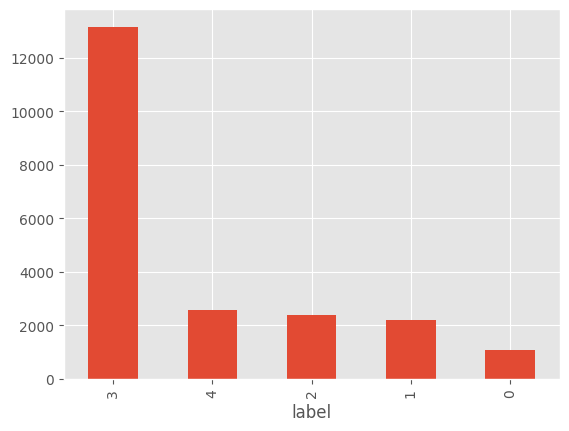

In [38]:
df.label.value_counts().plot(kind="bar")

In [39]:
# train과 test를 9:1로 나눠주세요.
# random_state은 자유롭게 지정 가능합니다.
train_df, valid_df = model_selection.train_test_split(
    df, test_size=0.1, random_state=123, stratify=df.label.values
)

In [47]:
class CassavaDataset(torch.utils.data.Dataset):

    def __init__(self, df, data_path=DATA_PATH, mode="train", transforms=None):
        super().__init__()
        self.df_data = df.values
        self.data_path = data_path
        self.transforms = transforms
        self.mode = mode
        self.data_dir = "train_images_unzip" if mode == "train" else "test_images"

    def __len__(self):
        return len(self.df_data)

    def __getitem__(self, index):
        img_name, label = self.df_data[index]
        img_path = os.path.join(self.data_path, self.data_dir, img_name)
        img = Image.open(img_path).convert("RGB")

        if self.transforms is not None:
            image = self.transforms(img)

        return image, label

In [41]:
#데이터 증강
transforms_train = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=0.3),
        transforms.RandomResizedCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
    ]
)

transforms_valid = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
    ]
)

In [42]:
#사용 가능한 ViT 모델 목록
##우리는 이중 vit_base_patch16_224를 사용합니다!
print("Available Vision Transformer Models: ")
timm.list_models("vit*")

Available Vision Transformer Models: 


['vit_7b_patch16_dinov3',
 'vit_base_mci_224',
 'vit_base_patch8_224',
 'vit_base_patch14_dinov2',
 'vit_base_patch14_reg4_dinov2',
 'vit_base_patch16_18x2_224',
 'vit_base_patch16_224',
 'vit_base_patch16_224_miil',
 'vit_base_patch16_384',
 'vit_base_patch16_clip_224',
 'vit_base_patch16_clip_384',
 'vit_base_patch16_clip_quickgelu_224',
 'vit_base_patch16_dinov3',
 'vit_base_patch16_dinov3_qkvb',
 'vit_base_patch16_gap_224',
 'vit_base_patch16_plus_240',
 'vit_base_patch16_plus_clip_240',
 'vit_base_patch16_reg4_gap_256',
 'vit_base_patch16_rope_224',
 'vit_base_patch16_rope_ape_224',
 'vit_base_patch16_rope_mixed_224',
 'vit_base_patch16_rope_mixed_ape_224',
 'vit_base_patch16_rope_reg1_gap_256',
 'vit_base_patch16_rpn_224',
 'vit_base_patch16_siglip_224',
 'vit_base_patch16_siglip_256',
 'vit_base_patch16_siglip_384',
 'vit_base_patch16_siglip_512',
 'vit_base_patch16_siglip_gap_224',
 'vit_base_patch16_siglip_gap_256',
 'vit_base_patch16_siglip_gap_384',
 'vit_base_patch16_siglip

### 모델 설계
- 클래스 ViTBase16의 각 줄을 설명하는 주석을 달아주세요. (최소 15개)

In [43]:
# 이 셀 안의 코드에 대해서 주석을 달아주세요.
class ViTBase16(nn.Module):
    def __init__(self, n_classes, pretrained=False):

        super(ViTBase16, self).__init__()

        # timm: 이미지 관련 작업을 처리할 수 있는 사전 훈련된 모델을 포함하는 라이브러리
        ## 파이토치 기반, 최신 컴퓨터비전 연구에서 사용되는 다양한 모델 아키텍처와 학습 기술 지원
        ## ResNet, EfficientNet, ViT 등이 있음

        # 사전 훈련된 모델 로드
        self.model = timm.create_model("vit_base_patch16_224", pretrained=False)
        if pretrained:
            self.model.load_state_dict(torch.load(MODEL_PATH))
            ## load_state_dict: copy parameters and buffers into self.model

        # ViT 모델 헤드 교체
        self.model.head = nn.Linear(self.model.head.in_features, n_classes)
        ## self.model.head: ViT 모델의 마지막 linear 레이어 (토큰 벡터->클래스 확률)
        ## 원래는 ImageNet (1000 classes) 에 맞춰져 있으니까 지금 데이터랑 출력 차원 맞춤

    def forward(self, x):
        x = self.model(x)
        return x

    # 1 epoch 학습
    def train_one_epoch(self, train_loader, criterion, optimizer, device):
        epoch_loss = 0.0
        epoch_accuracy = 0.0

        self.model.train()
        for i, (data, target) in enumerate(train_loader): # 로더로 전처리된 샘플에 대해
            # 장치 맞춤
            if device.type == "cuda":
                data, target = data.cuda(), target.cuda()
            elif device.type == "xla":
                data = data.to(device, dtype=torch.float32)
                target = target.to(device, dtype=torch.int64)

                ## xla(Accelerated Linear Algebra) = tpu(Tensor Processing Unit)
                ## 텐서플로 모델 가속 컴파일러
                ## 파이토치는 기본적으로 cpu, gpu를 지원하는데 xla를 통해 tpu로도 동작 가능

            optimizer.zero_grad() # 기울기 초기화
            output = self.forward(data) # 순전파
            loss = criterion(output, target) # 손실 계산
            loss.backward() # 역전파
            accuracy = (output.argmax(dim=1) == target).float().mean() # 정확도 계산
            ## 정답을 맞힌 경우에 대해

            # 이번 epoch 결과 누적
            epoch_loss += loss
            epoch_accuracy += accuracy

            if device.type == "xla":
                xm.optimizer_step(optimizer) # tpu로 옵티마이저 구동

                if i % 20 == 0: # 배치 20개마다 로그 출력
                    xm.master_print(f"\tBATCH {i+1}/{len(train_loader)} - LOSS: {loss}")

            else:
                optimizer.step()

        return epoch_loss / len(train_loader), epoch_accuracy / len(train_loader)

    # 1 epoch 검증
    def validate_one_epoch(self, valid_loader, criterion, device):
        valid_loss = 0.0
        valid_accuracy = 0.0

        self.model.eval()
        for data, target in valid_loader:
            if device.type == "cuda":
                data, target = data.cuda(), target.cuda()
            elif device.type == "xla":
                data = data.to(device, dtype=torch.float32)
                target = target.to(device, dtype=torch.int64)

            with torch.no_grad(): # 예측이니까 기울기 조정 x
                output = self.model(data)
                loss = criterion(output, target)
                accuracy = (output.argmax(dim=1) == target).float().mean()

                valid_loss += loss
                valid_accuracy += accuracy

        return valid_loss / len(valid_loader), valid_accuracy / len(valid_loader)

In [21]:
def fit_tpu(
    model, epochs, device, criterion, optimizer, train_loader, valid_loader=None
):

    valid_loss_min = np.inf

    train_losses = []
    valid_losses = []
    train_accs = []
    valid_accs = []

    for epoch in range(1, epochs + 1):
        gc.collect()
        para_train_loader = pl.ParallelLoader(train_loader, [device])

        xm.master_print(f"{'='*50}")
        xm.master_print(f"EPOCH {epoch} - TRAINING...")
        train_loss, train_acc = model.train_one_epoch(
            para_train_loader.per_device_loader(device), criterion, optimizer, device
        )
        xm.master_print(
            f"\n\t[TRAIN] EPOCH {epoch} - LOSS: {train_loss}, ACCURACY: {train_acc}\n"
        )
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        gc.collect()

        if valid_loader is not None:
            gc.collect()
            para_valid_loader = pl.ParallelLoader(valid_loader, [device])
            xm.master_print(f"EPOCH {epoch} - VALIDATING...")
            valid_loss, valid_acc = model.validate_one_epoch(
                para_valid_loader.per_device_loader(device), criterion, device
            )
            xm.master_print(f"\t[VALID] LOSS: {valid_loss}, ACCURACY: {valid_acc}\n")
            valid_losses.append(valid_loss)
            valid_accs.append(valid_acc)
            gc.collect()

            if valid_loss <= valid_loss_min and epoch != 1:
                xm.master_print(
                    "Validation loss decreased ({:.4f} --> {:.4f}).  Saving model ...".format(
                        valid_loss_min, valid_loss
                    )
                )

            valid_loss_min = valid_loss

    return {
        "train_loss": train_losses,
        "valid_losses": valid_losses,
        "train_acc": train_accs,
        "valid_acc": valid_accs,
    }

In [44]:
model = ViTBase16(n_classes=5, pretrained=True)

In [45]:
def _run():
    train_dataset = CassavaDataset(train_df, transforms=transforms_train)
    valid_dataset = CassavaDataset(valid_df, transforms=transforms_valid)

    train_sampler = torch.utils.data.distributed.DistributedSampler(
        train_dataset,
        num_replicas=torch_xla.runtime.world_size(),
        rank=torch_xla.runtime.global_ordinal(),
        shuffle=True,
    )

    valid_sampler = torch.utils.data.distributed.DistributedSampler(
        valid_dataset,
        num_replicas=torch_xla.runtime.world_size(),
        rank=torch_xla.runtime.global_ordinal(),
        shuffle=False,
    )

    train_loader = torch.utils.data.DataLoader(
        dataset=train_dataset,
        batch_size=BATCH_SIZE,
        sampler=train_sampler,
        drop_last=True,
        num_workers=8,
    )

    valid_loader = torch.utils.data.DataLoader(
        dataset=valid_dataset,
        batch_size=BATCH_SIZE,
        sampler=valid_sampler,
        drop_last=True,
        num_workers=8,
    )

    criterion = nn.CrossEntropyLoss()  #cross entropy loss로 설정.
    device = xm.xla_device()
    model.to(device)

    lr = LR * torch_xla.runtime.world_size()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    xm.master_print(f"INITIALIZING TRAINING ON {torch_xla.runtime.world_size()} TPU CORES")
    start_time = datetime.now()
    xm.master_print(f"Start Time: {start_time}")

    # xm 이용해서 모델 돌림
    logs = fit_tpu(
        model=model,
        epochs=N_EPOCHS,
        device=device,
        criterion=criterion,
        optimizer=optimizer,
        train_loader=train_loader,
        valid_loader=valid_loader,
    )

    xm.master_print(f"Execution time: {datetime.now() - start_time}")

    xm.master_print("Saving Model")
    xm.save(
        model.state_dict(), f'model_5e_{datetime.now().strftime("%Y%m%d-%H%M")}.pth'
    )

In [48]:
# Training 시작
def _mp_fn(rank, flags):
    torch.set_default_tensor_type("torch.FloatTensor")
    a = _run()


# Run
FLAGS = {}
xmp.spawn(_mp_fn, args=(FLAGS,), nprocs=1, start_method="fork")

/tmp/ipython-input-73593290.py:36: DeprecationWarning: Use torch_xla.device instead
  device = xm.xla_device()


INITIALIZING TRAINING ON 1 TPU CORES
Start Time: 2025-11-06 04:36:51.183430
EPOCH 1 - TRAINING...
	BATCH 1/1203 - LOSS: 1.703125
	BATCH 21/1203 - LOSS: 1.375
	BATCH 41/1203 - LOSS: 1.2109375
	BATCH 61/1203 - LOSS: 1.265625
	BATCH 81/1203 - LOSS: 1.0078125
	BATCH 101/1203 - LOSS: 1.0546875
	BATCH 121/1203 - LOSS: 1.328125
	BATCH 141/1203 - LOSS: 0.9296875
	BATCH 161/1203 - LOSS: 0.98828125
	BATCH 181/1203 - LOSS: 0.73828125
	BATCH 201/1203 - LOSS: 1.03125
	BATCH 221/1203 - LOSS: 0.65625
	BATCH 241/1203 - LOSS: 1.078125
	BATCH 261/1203 - LOSS: 0.96484375
	BATCH 281/1203 - LOSS: 1.6328125
	BATCH 301/1203 - LOSS: 1.3046875
	BATCH 321/1203 - LOSS: 1.0703125
	BATCH 341/1203 - LOSS: 1.3515625
	BATCH 361/1203 - LOSS: 0.91015625
	BATCH 381/1203 - LOSS: 1.0234375
	BATCH 401/1203 - LOSS: 0.8671875
	BATCH 421/1203 - LOSS: 1.4765625
	BATCH 441/1203 - LOSS: 1.140625
	BATCH 461/1203 - LOSS: 1.296875
	BATCH 481/1203 - LOSS: 1.0390625
	BATCH 501/1203 - LOSS: 0.73046875
	BATCH 521/1203 - LOSS: 0.9296875

In [25]:
# !pip show torch-xla

In [26]:
# from google.colab import drive
# drive.mount('/content/drive')